# 1) Chargement des données

Allez, cadeau 😘:

In [96]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "billets.csv"

if not os.path.exists(DATA_PATH):
    print(f"❌ Attention : le fichier '{DATA_PATH}' n'existe pas.")

try:
    df = pd.read_csv(DATA_PATH, sep=";")
    print("✅ Données chargées :", df.shape)
    display(df.head())
except Exception as e:
    print("❌ Erreur lors du chargement :", e)
    print("⚠️ Tu as bien lu le code avant de l'executer ? 😏")


✅ Données chargées : (1500, 7)


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


# 2) Analyse exploratoire (EDA)


Là, c'est vous les pro 💪, je vous fais entièrement confiance 😉 !

Pssst (indice) : trouvez des variables corrélées à votre objectif, ça marche mieux 😉.

In [97]:
# Infos générales
df.info()

# Statistiques descriptives
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


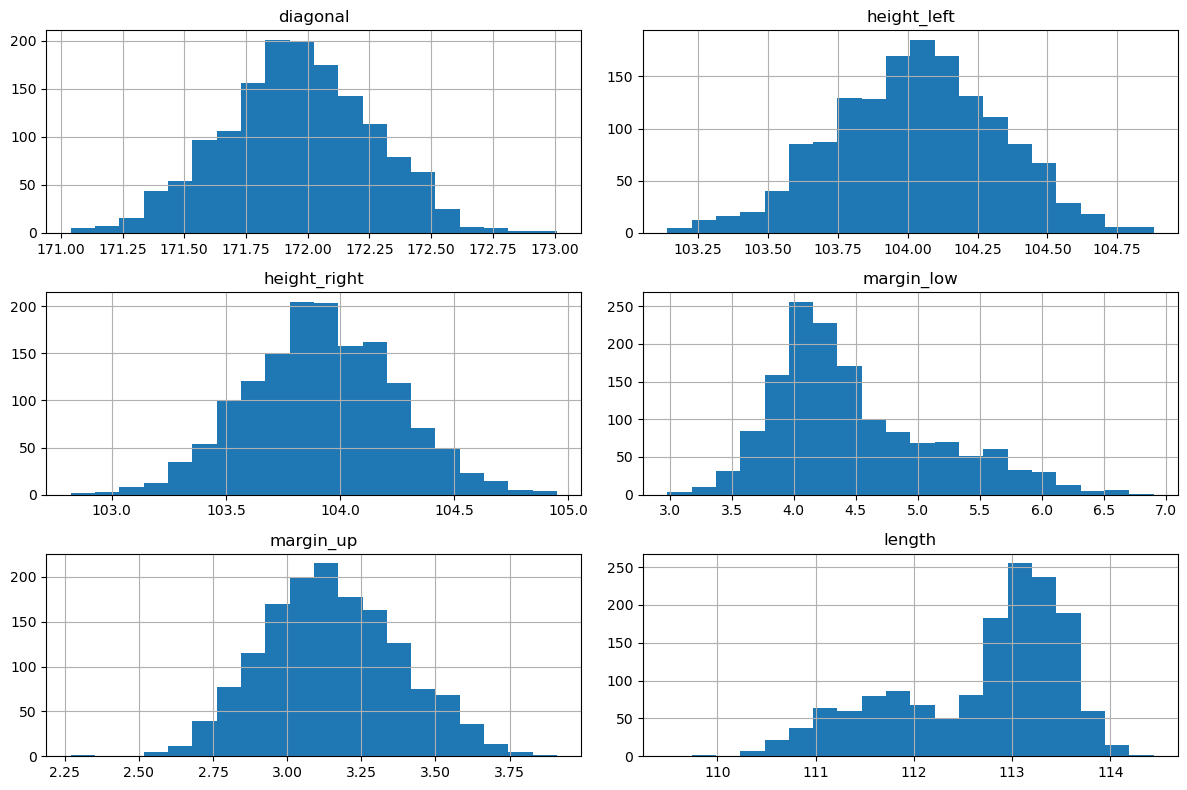

In [98]:
df.hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

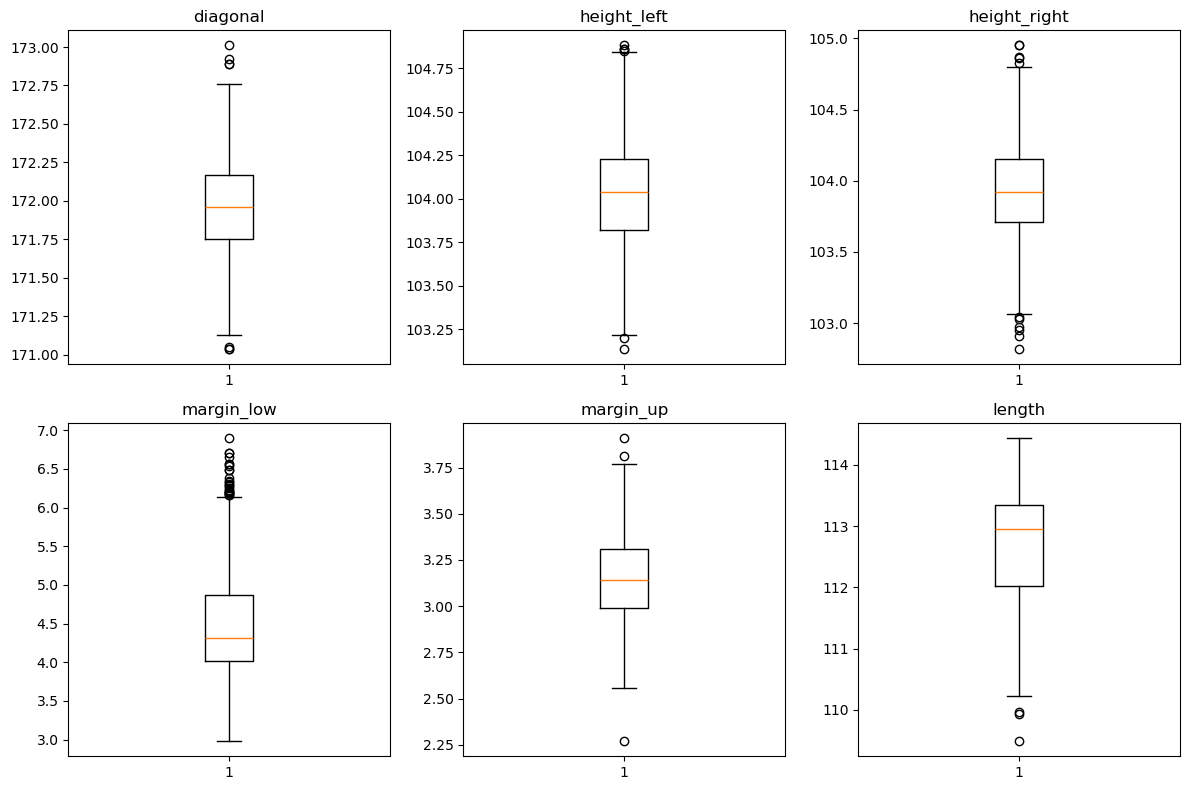

In [99]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

cols = df.columns.drop("is_genuine")

for i, col in enumerate(cols):
    ax = axes[i // 3, i % 3]
    ax.boxplot(df[col].dropna())
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [100]:
import seaborn as sns

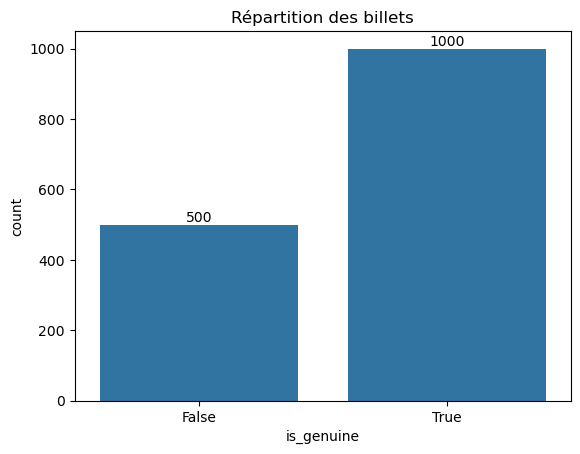

In [101]:
sns.countplot(x="is_genuine", data=df, )
plt.title("Répartition des billets")
plt.bar_label(plt.gca().containers[0])
plt.show()

In [ ]:
# Moyenne des variables par type de billet
mean_by_class = X.assign(is_genuine=y).groupby("is_genuine").mean()

# Diagramme en barres
mean_by_class.T.plot(kind="bar", figsize=(10, 6))

plt.title("Moyenne des variables selon le type de billet")
plt.xlabel("Variables")
plt.ylabel("Valeur moyenne")
plt.legend(["Faux", "Vrai"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

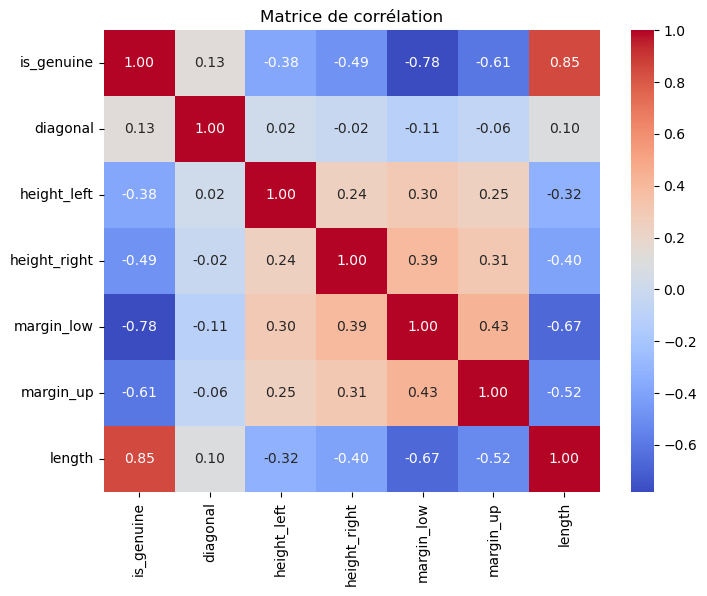

In [103]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

In [104]:
df_true_bill = df[df["is_genuine"] == 1]
df_true_bill = df_true_bill.drop(columns=["is_genuine"])
df_fake_bill = df[df["is_genuine"] == 0]
df_fake_bill = df_fake_bill.drop(columns=["is_genuine"])

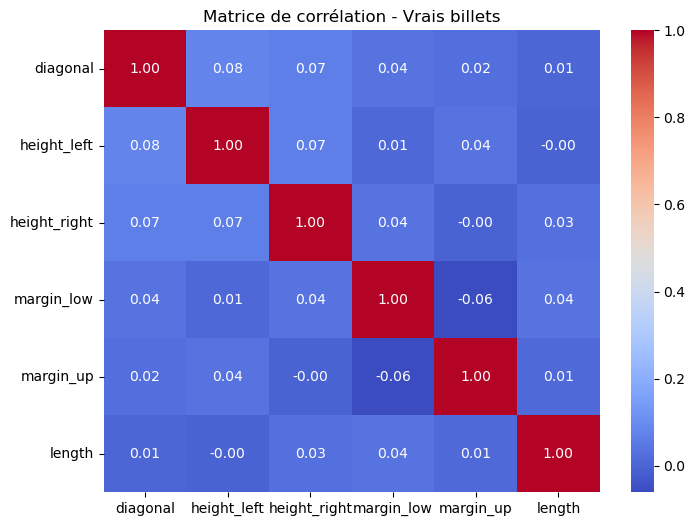

In [105]:
# Affichage de la matrice de corrélation pour les lignes où is_genuine == 1
plt.figure(figsize=(8, 6))
sns.heatmap(df_true_bill.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation - Vrais billets")
plt.show()

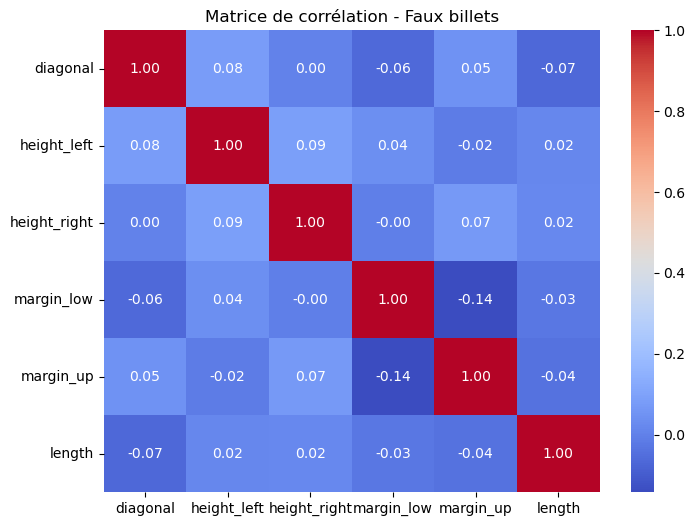

In [106]:
# Affichage de la matrice de corrélation pour les lignes où is_genuine == 1
plt.figure(figsize=(8, 6))
sns.heatmap(df_fake_bill.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation - Faux billets")
plt.show()

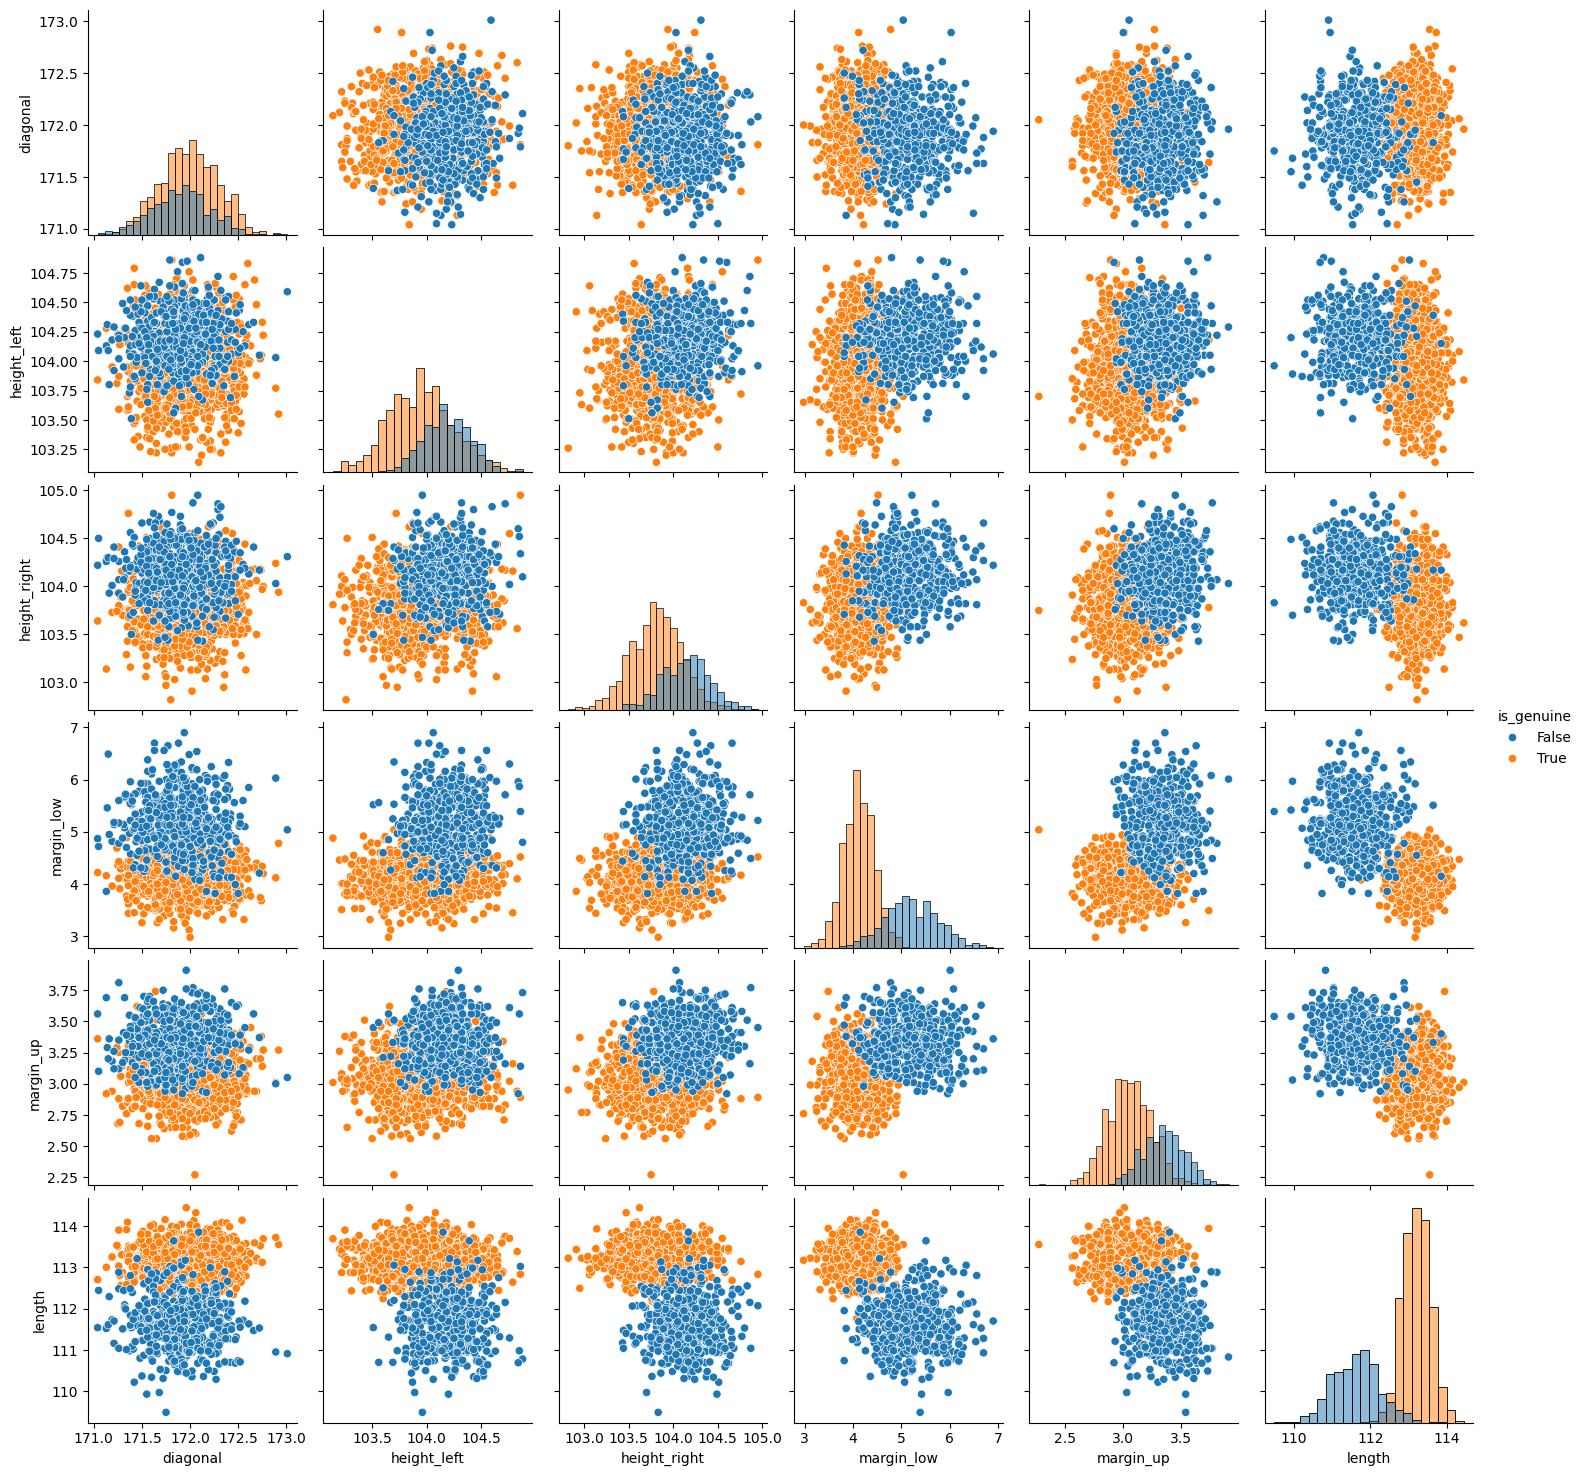

In [107]:
sns.pairplot(df, hue="is_genuine", diag_kind="hist")

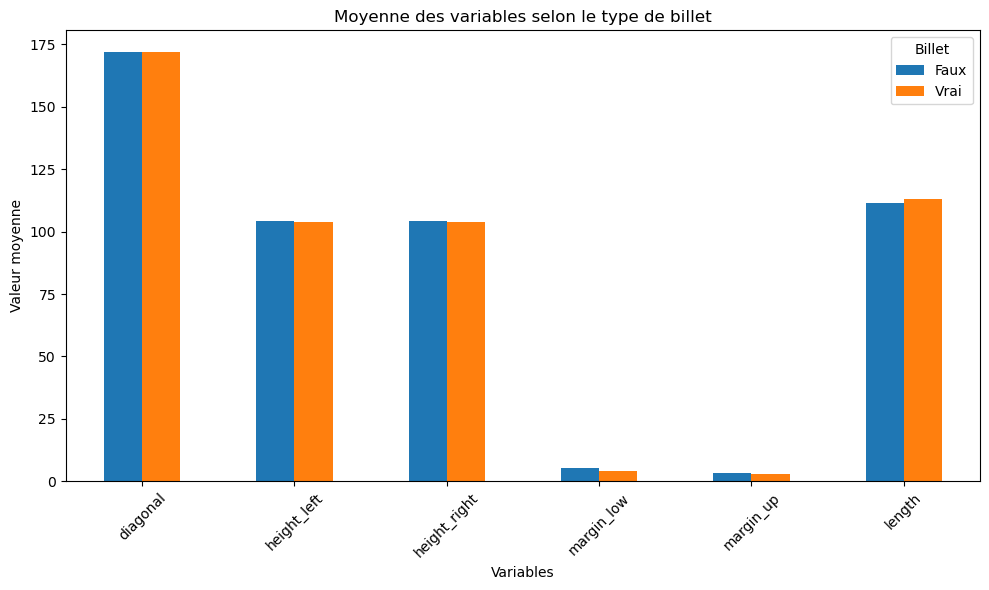

In [190]:
mean_by_class = df.groupby("is_genuine").mean(numeric_only=True)

# Diagramme en barres
mean_by_class.T.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Moyenne des variables selon le type de billet")
plt.xlabel("Variables")
plt.ylabel("Valeur moyenne")
plt.legend(title="Billet", labels=["Faux", "Vrai"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3) Prétraitement

Le but est de transformer tes données brutes (les valeurs mesurées des billets) en données que les algorithmes de Machine Learning peuvent comprendre efficacement.


D'abord, il faut séparer les variables explicatives et la cible :

X = les mesures du billet (longueur, hauteur, diagonales…)

y = l’étiquette (vrai ou faux)

➡️ Pourquoi ?
Parce que le modèle doit apprendre à prédire y en fonction de X.

In [191]:
df["is_fake"] = 1 - df["is_genuine"]

In [192]:
X = df.drop(columns=["is_genuine", "is_fake"]) # Toutes les colonnes sauf la cible
y = df["is_fake"] # La colonne cible

Autre point important : on entraîne toujours le modèle sur un morceau des données, et on teste sur un autre qu’il n’a jamais vu.

➡️ Pourquoi ?
Pour éviter le sur-apprentissage (le modèle apprend par cœur sans savoir généraliser).

### Remplacement des Nan


In [193]:
#################################################################################

# Split la donnée une première fois pour trouver margin low / Puis resplit pour les entrainement d'algo

##################################################################################

In [194]:
from sklearn.model_selection import train_test_split

# utilisez train_test_split de la librairy Sklearn
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Permet d'avoir la même proportion de classes dans les sets d'entraînement et de test
)

print("Train :", X_train.shape)
print("Test :", X_test.shape) 

Train : (1200, 6)
Test : (300, 6)


In [195]:
from sklearn.linear_model import LinearRegression

# Entraîner le modèle uniquement sur les données d'entraînement
train_non_null = X_train[X_train["margin_low"].notna()]

reg = LinearRegression()
reg.fit(
    train_non_null[["length"]],
    train_non_null["margin_low"]
)

# Remplacer les NaN du train
mask_train = X_train["margin_low"].isna()
X_train.loc[mask_train, "margin_low"] = reg.predict(
    X_train.loc[mask_train, ["length"]]
)

# Remplacer les NaN du test avec le même modèle
mask_test = X_test["margin_low"].isna()
X_test.loc[mask_test, "margin_low"] = reg.predict(
    X_test.loc[mask_test, ["length"]]
)

In [196]:
print("NaN dans margin_low (train) :", X_train["margin_low"].isna().sum())
print("NaN dans margin_low (test) :", X_test["margin_low"].isna().sum())

NaN dans margin_low (train) : 0
NaN dans margin_low (test) : 0


Enfin, on met toutes les variables sur la même échelle (moyenne = 0, écart-type = 1).

➡️ Pourquoi ?
Parce que certains modèles, comme le KNN ou la Régression Logistique, sont sensibles aux différences d’échelle.
Sans standardisation, la variable la plus grande numériquement prend trop d’importance.

In [197]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Use scaler on X_train and X_test.

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4) Modélisation

Dans tous domaines, vous ne pouvez pas progresser si vous ne comprenez pas comment vos outils fonctionnent.

Avant d'utiliser les modèles mathématiques qui suivent, je vous recommande donc de visionner les vidéos suivantes:
* [StatQuest: Logistic Regression](https://www.youtube.com/watch?v=yIYKR4sgzI8)
* [StatQuest: K-nearest neighbors, Clearly Explained](https://youtu.be/HVXime0nQeI)
* [StatQuest: Random Forests Part 1 - Building, Using and Evaluating](https://youtu.be/J4Wdy0Wc_xQ)
* [StatQuest: Random Forests Part 2: Missing data and clustering](https://www.youtube.com/watch?v=sQ870aTKqiM)
* [StatQuest: K-means clustering](https://youtu.be/4b5d3muPQmA)

## Regression logistique

In [113]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report

In [114]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

In [ ]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)

grid_log = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv= 3, #CV 2~3. Verifier si c'est stratifié ou pas ##################################
    scoring="recall",
    n_jobs=-1
)

grid_log.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'],
                         'solver': ['lbfgs']},
             scoring='recall')

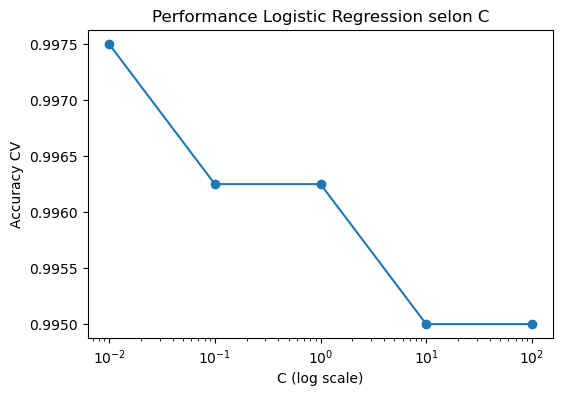

In [116]:
results = pd.DataFrame(grid_log.cv_results_)

plt.figure(figsize=(6,4))
plt.plot(results["param_C"], results["mean_test_score"], marker='o')
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("Accuracy CV")
plt.title("Performance Logistic Regression selon C")
plt.show()

In [117]:
print("Meilleurs paramètres :", grid_log.best_params_)
print("Meilleur score CV :", grid_log.best_score_)

Meilleurs paramètres : {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Meilleur score CV : 0.9974999999999999


In [118]:
# 1) Initialisez une régression logistic.
    # Quels sont les paramètres ajustables de ce modèle ?
    # Bien que vous puissez laisser la majorité d'entre eux par défaut,
    # il vaut mieux, à minima, ajuster `max_iter` pour plafonner le temps de calcul.
model = LogisticRegression(max_iter=1000, random_state=42, C=grid_log.best_params_["C"], penalty=grid_log.best_params_["penalty"], solver=grid_log.best_params_["solver"])
# 2) Entrainez le modèle avec vos données X_train et y_train
model.fit(X_train_scaled, y_train)

# 3) Utiliser la régression logistique pour déterminer les vrais / faux billets de X_test.
y_pred_log = model.predict(X_test_scaled)

In [119]:
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

[[ 97   3]
 [  1 199]]
              precision    recall  f1-score   support

       False       0.99      0.97      0.98       100
        True       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.98      0.98       300
weighted avg       0.99      0.99      0.99       300



In [120]:
#Score de la régression logistique
print("Score de la Régression Logistique TRAIN:", model.score(X_train_scaled, y_train))
#Score de la régression logistique
print("Score de la Régression Logistique TEST:", model.score(X_test_scaled, y_test))

Score de la Régression Logistique TRAIN: 0.9833333333333333
Score de la Régression Logistique TEST: 0.9866666666666667


## KNN

In [121]:
from sklearn.neighbors import KNeighborsClassifier

# Répéter les même étapes que pour la régression logistique mais avec le KNN.

In [122]:
param_grid = {
    "n_neighbors": list(range(1, 21)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean"]
}

In [123]:
knn = KNeighborsClassifier()

grid = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,              # validation croisée à 5 folds
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean'],
                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19, 20],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [124]:
results = pd.DataFrame(grid.cv_results_)

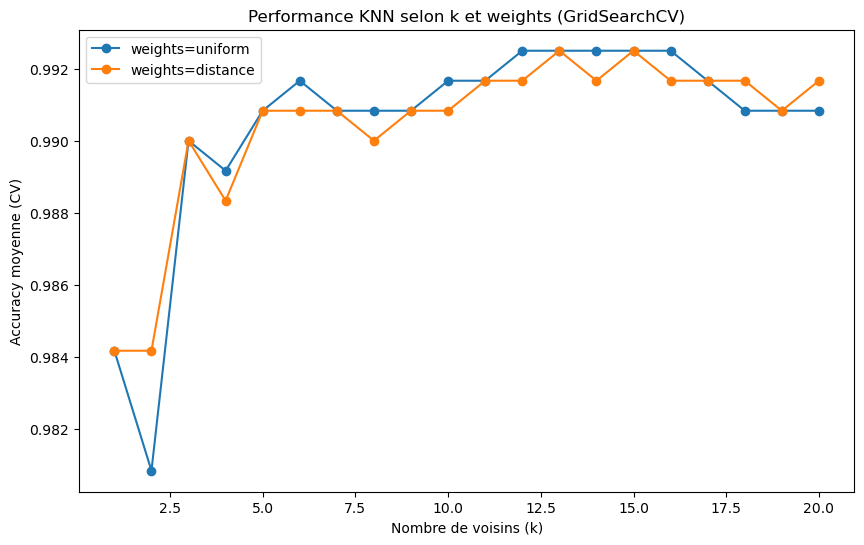

In [125]:
plt.figure(figsize=(10, 6))

# On filtre uniquement les résultats avec metric euclidean
subset = results[results["param_metric"] == "euclidean"]

for weight in subset["param_weights"].unique():
    temp = subset[subset["param_weights"] == weight]
    plt.plot(
        temp["param_n_neighbors"],
        temp["mean_test_score"],
        marker='o',
        label=f"weights={weight}"
    )

plt.xlabel("Nombre de voisins (k)")
plt.ylabel("Accuracy moyenne (CV)")
plt.title("Performance KNN selon k et weights (GridSearchCV)")
plt.legend()
plt.show()

In [126]:
print("Meilleurs paramètres :", grid.best_params_)
print("Meilleur score CV :", grid.best_score_)

Meilleurs paramètres : {'metric': 'euclidean', 'n_neighbors': 12, 'weights': 'uniform'}
Meilleur score CV : 0.9925


In [127]:
# n_neighbors = nombre de voisins (hyperparamètre principal)
knn = KNeighborsClassifier(**grid.best_params_)

# 2) Entraînement du modèle
knn.fit(X_train_scaled, y_train)

# 3) Prédictions
y_pred_knn = knn.predict(X_test_scaled)

In [128]:
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

[[ 99   1]
 [  1 199]]
              precision    recall  f1-score   support

       False       0.99      0.99      0.99       100
        True       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



In [129]:
#Score de la régression logistique
print("Score du KNN TRAIN:", knn.score(X_train_scaled, y_train))
#Score de la régression logistique
print("Score du KNN TEST:", knn.score(X_test_scaled, y_test))

Score du KNN TRAIN: 0.9916666666666667
Score du KNN TEST: 0.9933333333333333


## Random Forest Classifier

In [130]:
from sklearn.ensemble import RandomForestClassifier

In [131]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [132]:
rf = RandomForestClassifier(random_state=42)

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_rf.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [133]:
results = pd.DataFrame(grid_rf.cv_results_)

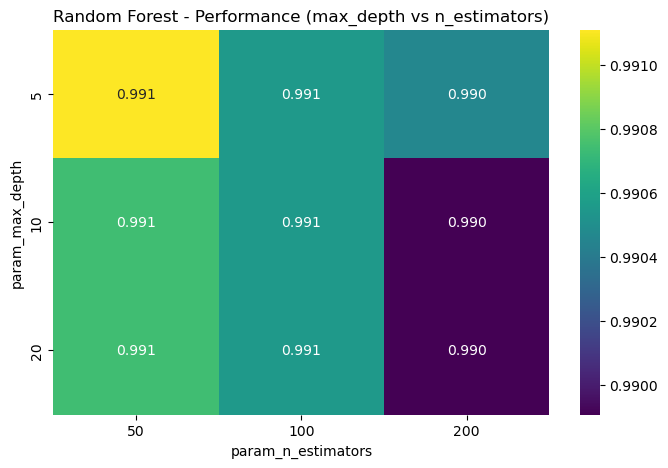

In [134]:
pivot = results.pivot_table(
    values="mean_test_score",
    index="param_max_depth",
    columns="param_n_estimators"
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("Random Forest - Performance (max_depth vs n_estimators)")
plt.show()

In [135]:
print("Meilleurs paramètres :", grid_rf.best_params_)
print("Meilleur score CV :", grid_rf.best_score_)

Meilleurs paramètres : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
Meilleur score CV : 0.9916666666666666


In [136]:
# hum... devinez ce qu'il faut faire 😁.

# n_estimators = nombre d'arbres (plus il est élevé, plus le modèle est stable)
rf = RandomForestClassifier(**grid_rf.best_params_, random_state=42)

# 2) Entraînement
rf.fit(X_train_scaled, y_train)

# 3) Prédictions
y_pred_rf = rf.predict(X_test_scaled)

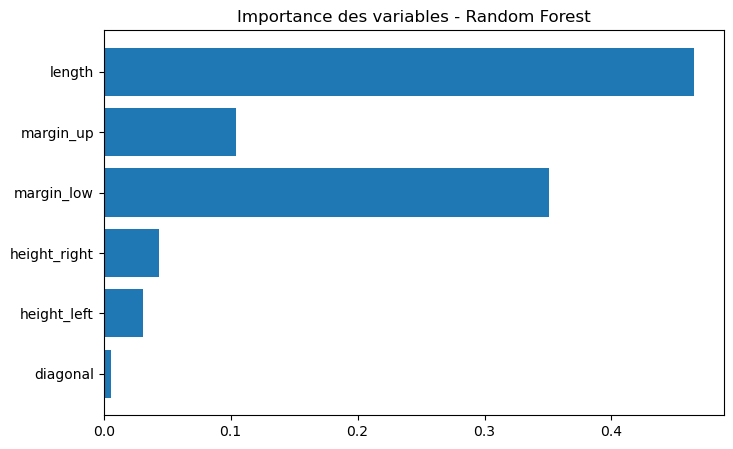

In [137]:
importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(8, 5))
plt.barh(features, importances)
plt.title("Importance des variables - Random Forest")
plt.show()

In [138]:
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[ 98   2]
 [  1 199]]
              precision    recall  f1-score   support

       False       0.99      0.98      0.98       100
        True       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



In [139]:
#Score de la régression logistique
print("Score du Random Forest TRAIN:", rf.score(X_train_scaled, y_train))
#Score de la régression logistique
print("Score du Random Forest TEST:", rf.score(X_test_scaled, y_test))

Score du Random Forest TRAIN: 0.9991666666666666
Score du Random Forest TEST: 0.99


## K-Means

In [140]:
from sklearn.cluster import KMeans

# Attention ! Cet algo est très différents de ceux utilisés précédemment.
# Peux-tu voir les différences ?
# Du coup, cet algo est-il utile (voir pertinent) pour cette étude ?

# On entraîne sur les données non supervisées
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

kmeans.fit(X_train_scaled)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


KMeans(n_clusters=2, n_init=10, random_state=42)

In [141]:
train_clusters = kmeans.labels_
test_clusters = kmeans.predict(X_test_scaled)

In [142]:
# On regarde quel cluster correspond à quoi
cluster_mapping = {}

for cluster in [0, 1]:
    mask = (train_clusters == cluster)
    cluster_mapping[cluster] = y_train[mask].mode()[0]

cluster_mapping

{0: False, 1: True}

In [143]:
y_pred_kmeans = np.array([cluster_mapping[c] for c in test_clusters])

In [144]:
print("Inertie (K-means) :", kmeans.inertia_)

Inertie (K-means) : 4644.976906131257


In [145]:
print(confusion_matrix(y_test, y_pred_kmeans))
print(classification_report(y_test, y_pred_kmeans))

[[ 98   2]
 [  2 198]]
              precision    recall  f1-score   support

       False       0.98      0.98      0.98       100
        True       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.99      0.99      0.99       300



In [146]:
#Score de la régression logistique
print("Score du KMeans TRAIN:", kmeans.score(X_train_scaled, y_train))
#Score de la régression logistique
print("Score du KMeans TEST:", kmeans.score(X_test_scaled, y_test))

Score du KMeans TRAIN: -4644.976906131257
Score du KMeans TEST: -1255.4421075450032


## Ajout de modèles supplémentaires
(SVM, Decision Tree, Naive Bayes)

In [147]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

### SVM (Support Vector Machine)

In [148]:
param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["rbf", "linear"]
}

In [149]:
svm = SVC()

grid_svm = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,              # validation croisée à 5 folds
    scoring="accuracy",
    n_jobs=-1
)

grid_svm.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear']},
             scoring='accuracy')

In [150]:
results = pd.DataFrame(grid_svm.cv_results_)

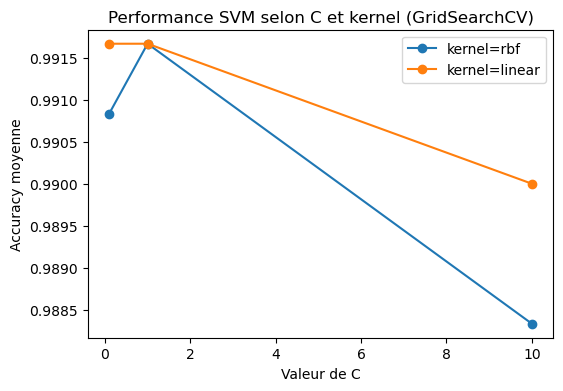

In [151]:
# Graphique montrant la performance du SVM en fonction de C et kernel
plt.figure(figsize=(6,4))
for kernel in param_grid["kernel"]:
    subset = results[results["param_kernel"] == kernel]
    plt.plot(
        subset["param_C"],
        subset["mean_test_score"],
        marker='o',
        label=f"kernel={kernel}"
    )
plt.xlabel("Valeur de C")
plt.ylabel("Accuracy moyenne")
plt.title("Performance SVM selon C et kernel (GridSearchCV)")
plt.legend()
plt.show()

In [152]:
print("Meilleurs paramètres :", grid_svm.best_params_)
print("Meilleur score CV :", grid_svm.best_score_)

Meilleurs paramètres : {'C': 1, 'kernel': 'rbf'}
Meilleur score CV : 0.9916666666666668


In [153]:
svm = SVC(**grid_svm.best_params_, probability=True, random_state=42)

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

In [154]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("===== SVM =====")
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

===== SVM =====
Accuracy : 0.9933333333333333
[[ 99   1]
 [  1 199]]
              precision    recall  f1-score   support

       False       0.99      0.99      0.99       100
        True       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



### Decision Tree

In [155]:
param_grid = {
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10]
}

In [156]:
tree = DecisionTreeClassifier()

grid_tree = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    cv=5,              # validation croisée à 5 folds
    scoring="accuracy",
    n_jobs=-1
)

grid_tree.fit(X_train, y_train) # Pas besoin d'avoir les données scalées pour un arbre de décision

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 20],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [157]:
results = pd.DataFrame(grid_tree.cv_results_)

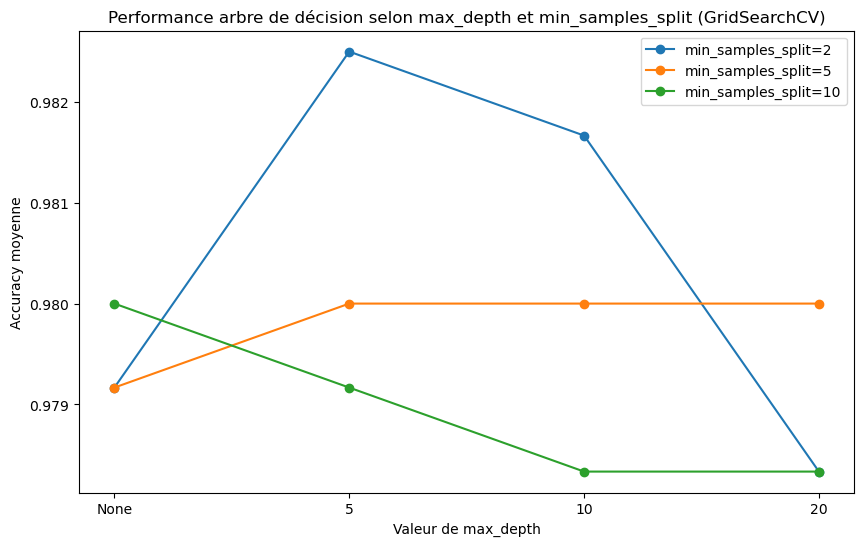

In [158]:
# Graphique montrant la performance du tree en fonction de max_depth et min_samples_split
plt.figure(figsize=(10, 6))
for min_samples_split in param_grid["min_samples_split"]:
    subset = results[results["param_min_samples_split"] == min_samples_split]
    plt.plot(
        subset["param_max_depth"].apply(lambda x: "None" if x is None else str(x)),
        subset["mean_test_score"],
        marker='o',
        label=f"min_samples_split={min_samples_split}"
    )
plt.xlabel("Valeur de max_depth")
plt.ylabel("Accuracy moyenne")
plt.title("Performance arbre de décision selon max_depth et min_samples_split (GridSearchCV)")
plt.legend()
plt.show()



In [159]:
print("Meilleurs paramètres :", grid_tree.best_params_)
print("Meilleur score CV :", grid_tree.best_score_)

Meilleurs paramètres : {'max_depth': 5, 'min_samples_split': 2}
Meilleur score CV : 0.9824999999999999


In [160]:
tree = DecisionTreeClassifier(**grid_tree.best_params_, random_state=42)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

In [161]:
print("===== Decision Tree =====")
print("Accuracy :", accuracy_score(y_test, y_pred_tree))
print(confusion_matrix(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

===== Decision Tree =====
Accuracy : 0.9833333333333333
[[ 98   2]
 [  3 197]]
              precision    recall  f1-score   support

       False       0.97      0.98      0.98       100
        True       0.99      0.98      0.99       200

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



### Naive Bayes

In [162]:
nb = GaussianNB()

nb.fit(X_train_scaled, y_train)

y_pred_nb = nb.predict(X_test_scaled)

In [163]:
print("===== Naive Bayes =====")
print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print(confusion_matrix(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

===== Naive Bayes =====
Accuracy : 0.99
[[ 98   2]
 [  1 199]]
              precision    recall  f1-score   support

       False       0.99      0.98      0.98       100
        True       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



# Analyse de la stabilité des modèles (impact du random_state)

In [164]:
from sklearn.metrics import accuracy_score
random_states = range(0, 50)

## Regression logistique

In [165]:
accuracies_log = []

for rs in random_states:
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=rs
    )
    
    mean_margin_low = X_train["margin_low"].mean()
    X_train = X_train.fillna(mean_margin_low)
    X_test = X_test.fillna(mean_margin_low)
    
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model = LogisticRegression(max_iter=1000, **grid_log.best_params_)
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    
    accuracies_log.append(accuracy_score(y_test, y_pred))

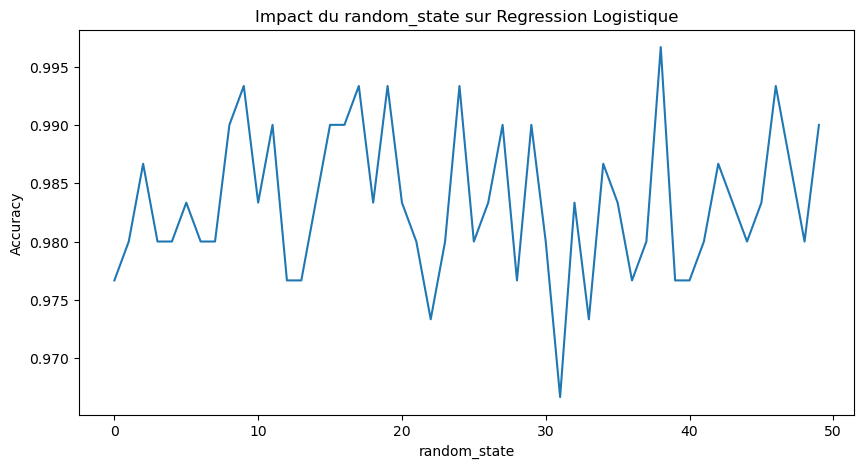

In [166]:
plt.figure(figsize=(10, 5))
plt.plot(random_states, accuracies_log)
plt.xlabel("random_state")
plt.ylabel("Accuracy")
plt.title("Impact du random_state sur Regression Logistique")
plt.show()

## KNN

In [167]:
accuracies_knn = []

for rs in random_states:
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=rs
    )
    
    mean_margin_low = X_train["margin_low"].mean()
    X_train = X_train.fillna(mean_margin_low)
    X_test = X_test.fillna(mean_margin_low)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    knn = KNeighborsClassifier(**grid.best_params_)
    knn.fit(X_train_scaled, y_train)
    
    y_pred = knn.predict(X_test_scaled)
    
    accuracies_knn.append(accuracy_score(y_test, y_pred))

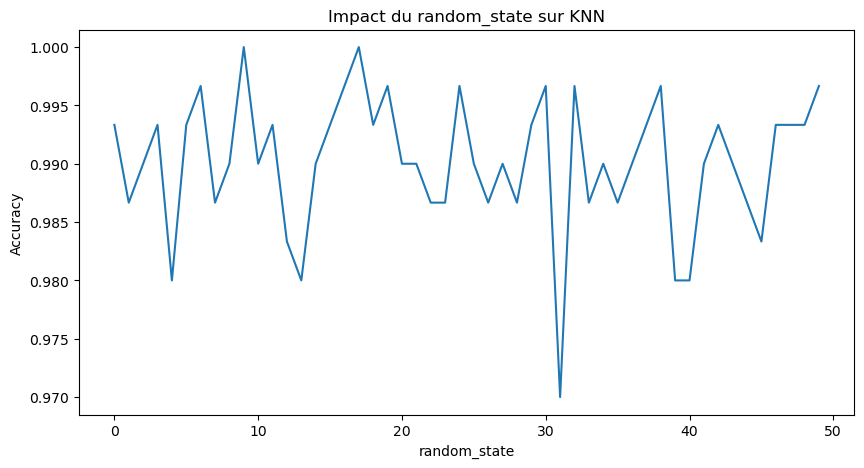

In [168]:
plt.figure(figsize=(10, 5))
plt.plot(random_states, accuracies_knn)
plt.xlabel("random_state")
plt.ylabel("Accuracy")
plt.title("Impact du random_state sur KNN")
plt.show()

## Random Forest

In [169]:
accuracies_rf = []

for rs in random_states:
    
    # split différent à chaque fois
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=rs
    )
    
    # gestion NaN
    mean_margin_low = X_train["margin_low"].mean()
    X_train = X_train.fillna(mean_margin_low)
    X_test = X_test.fillna(mean_margin_low)
    
    # scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # modèle
    rf = RandomForestClassifier(**grid_rf.best_params_, random_state=rs)
    rf.fit(X_train_scaled, y_train)
    
    y_pred = rf.predict(X_test_scaled)
    
    accuracies_rf.append(accuracy_score(y_test, y_pred))

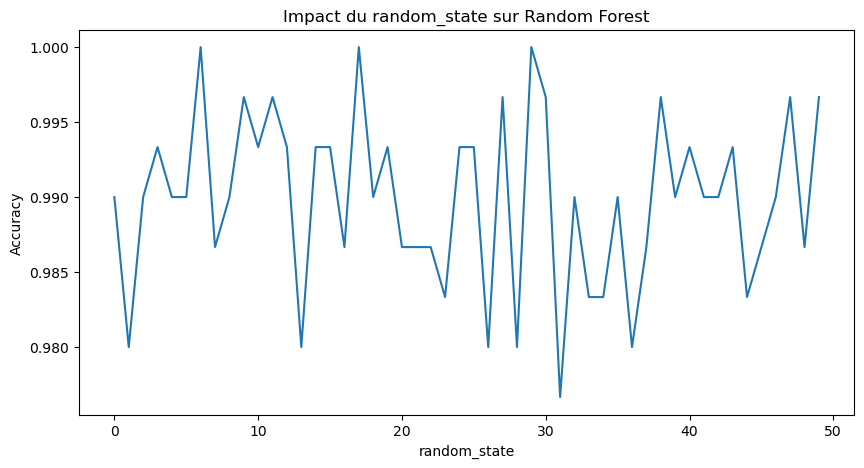

In [170]:
plt.figure(figsize=(10, 5))
plt.plot(random_states, accuracies_rf)
plt.xlabel("random_state")
plt.ylabel("Accuracy")
plt.title("Impact du random_state sur Random Forest")
plt.show()

## SVM

In [171]:
accuracies_svm = []

for rs in random_states:
    
    # split différent à chaque fois
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=rs
    )
    
    # gestion NaN
    mean_margin_low = X_train["margin_low"].mean()
    X_train = X_train.fillna(mean_margin_low)
    X_test = X_test.fillna(mean_margin_low)
    
    # scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # modèle
    svm = SVC(**grid_svm.best_params_, probability=True, random_state=rs)
    svm.fit(X_train_scaled, y_train)
    
    y_pred = svm.predict(X_test_scaled)
    
    accuracies_svm.append(accuracy_score(y_test, y_pred))

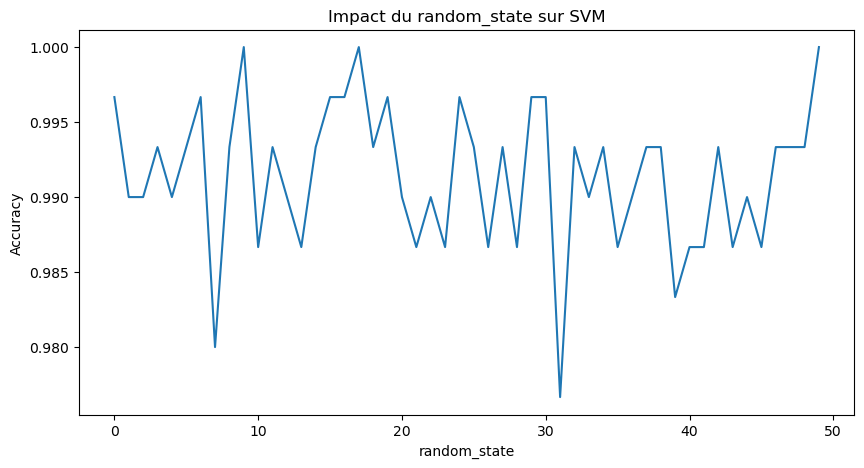

In [172]:
plt.figure(figsize=(10, 5))
plt.plot(random_states, accuracies_svm)
plt.xlabel("random_state")
plt.ylabel("Accuracy")
plt.title("Impact du random_state sur SVM")
plt.show()

## Decision Tree

In [173]:
accuracies_tree = []

for rs in random_states:
    
    # split différent à chaque fois
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=rs
    )
    
    # gestion NaN
    mean_margin_low = X_train["margin_low"].mean()
    X_train = X_train.fillna(mean_margin_low)
    X_test = X_test.fillna(mean_margin_low)
    
    # modèle
    tree = DecisionTreeClassifier(**grid_tree.best_params_, random_state=rs)
    tree.fit(X_train, y_train)
    
    y_pred = tree.predict(X_test)
    
    accuracies_tree.append(accuracy_score(y_test, y_pred))

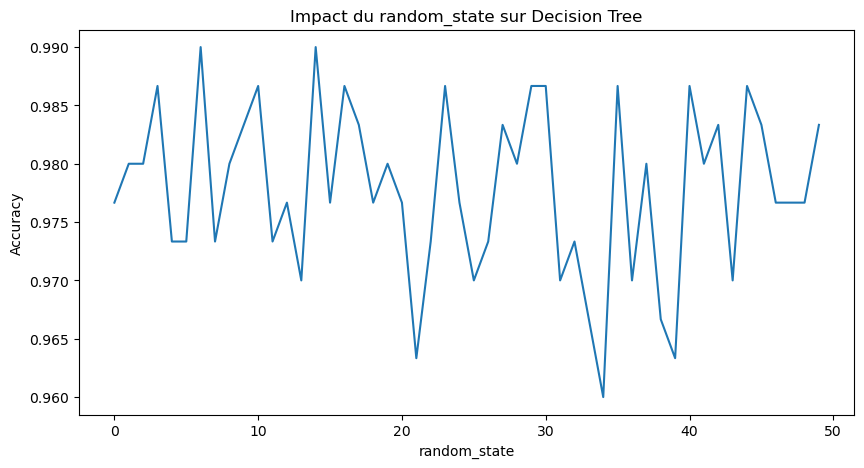

In [174]:
plt.figure(figsize=(10, 5))
plt.plot(random_states, accuracies_tree)
plt.xlabel("random_state")
plt.ylabel("Accuracy")
plt.title("Impact du random_state sur Decision Tree")
plt.show()

## Naive Bayes

In [175]:
accuracies_nb = []

for rs in random_states:
    
    # split différent à chaque fois
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=rs
    )
    
    # gestion NaN
    mean_margin_low = X_train["margin_low"].mean()
    X_train = X_train.fillna(mean_margin_low)
    X_test = X_test.fillna(mean_margin_low)
    
    # scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # modèle
    nb = GaussianNB()
    nb.fit(X_train_scaled, y_train)
    
    y_pred = nb.predict(X_test_scaled)
    
    accuracies_nb.append(accuracy_score(y_test, y_pred))

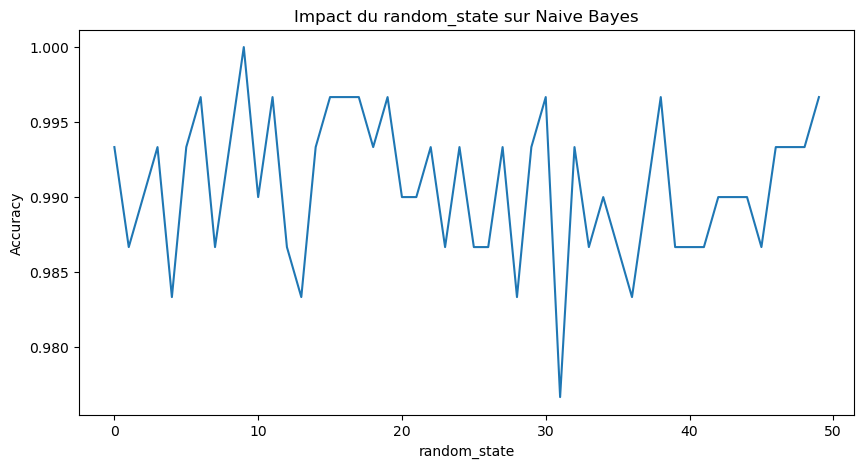

In [176]:
plt.figure(figsize=(10, 5))
plt.plot(random_states, accuracies_nb)
plt.xlabel("random_state")
plt.ylabel("Accuracy")
plt.title("Impact du random_state sur Naive Bayes")
plt.show()

## Comparaison

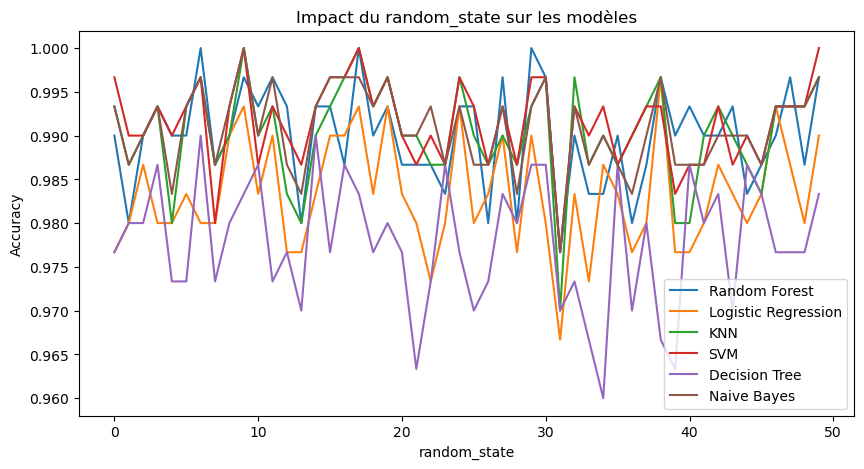

In [177]:
plt.figure(figsize=(10, 5))

plt.plot(random_states, accuracies_rf, label="Random Forest")
plt.plot(random_states, accuracies_log, label="Logistic Regression")
plt.plot(random_states, accuracies_knn, label="KNN")
plt.plot(random_states, accuracies_svm, label="SVM")
plt.plot(random_states, accuracies_tree, label="Decision Tree")
plt.plot(random_states, accuracies_nb, label="Naive Bayes")


plt.xlabel("random_state")
plt.ylabel("Accuracy")
plt.title("Impact du random_state sur les modèles")
plt.legend()
plt.show()

Cette analyse montre que les performances des modèles varient très peu en fonction du random_state.  
Cela indique que les modèles sont globalement stables et que les résultats obtenus ne dépendent pas fortement du découpage des données.  

Cette stabilité confirme que les données sont bien structurées et que les modèles généralisent correctement.

# Analyse de la robustesse des modèles (validation croisée)

In [178]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer

# Pipelines complets
pipeline_log = make_pipeline(
    SimpleImputer(strategy="mean"),
    StandardScaler(),
    LogisticRegression(**grid_log.best_params_)
)

pipeline_knn = make_pipeline(
    SimpleImputer(strategy="mean"),
    StandardScaler(),
    KNeighborsClassifier(**grid.best_params_)
)

pipeline_rf = make_pipeline(
    SimpleImputer(strategy="mean"),
    StandardScaler(),
    RandomForestClassifier(**grid_rf.best_params_, random_state=42)
)

pipeline_svm = make_pipeline(
    SimpleImputer(strategy="mean"),
    StandardScaler(),
    SVC(**grid_svm.best_params_, probability=True, random_state=42)
)

pipeline_tree = make_pipeline(
    SimpleImputer(strategy="mean"),
    StandardScaler(),
    DecisionTreeClassifier(**grid_tree.best_params_, random_state=42)
)

pipeline_nb = make_pipeline(
    SimpleImputer(strategy="mean"),
    StandardScaler(),
    GaussianNB()
)

In [179]:
from sklearn.model_selection import cross_val_score

cv = 5  # 5-fold cross-validation

scores_log = cross_val_score(pipeline_log, X, y, cv=cv, scoring="accuracy")
scores_knn = cross_val_score(pipeline_knn, X, y, cv=cv, scoring="accuracy")
scores_rf = cross_val_score(pipeline_rf, X, y, cv=cv, scoring="accuracy")
scores_svm = cross_val_score(pipeline_svm, X, y, cv=cv, scoring="accuracy")
scores_tree = cross_val_score(pipeline_tree, X, y, cv=cv, scoring="accuracy")
scores_nb = cross_val_score(pipeline_nb, X, y, cv=cv, scoring="accuracy")

In [180]:
def display_scores(name, scores):
    print(f"\n{name}")
    print("Scores :", scores)
    print("Moyenne :", scores.mean())
    print("Écart-type :", scores.std())

display_scores("Logistic Regression", scores_log)
display_scores("KNN", scores_knn)
display_scores("Random Forest", scores_rf)
display_scores("SVM", scores_svm)
display_scores("Decision Tree", scores_tree)
display_scores("Naive Bayes", scores_nb)


Logistic Regression
Scores : [0.97       0.98       0.99333333 0.99       0.98333333]
Moyenne : 0.9833333333333334
Écart-type : 0.008164965809277258

KNN
Scores : [0.98333333 0.98666667 0.99333333 0.99333333 0.99      ]
Moyenne : 0.9893333333333333
Écart-type : 0.0038873012632301947

Random Forest
Scores : [0.99333333 0.98333333 0.99666667 0.99666667 0.98666667]
Moyenne : 0.9913333333333332
Écart-type : 0.005416025603090661

SVM
Scores : [0.98666667 0.99       0.99666667 0.99       0.99333333]
Moyenne : 0.9913333333333332
Écart-type : 0.00339934634239519

Decision Tree
Scores : [0.97333333 0.97       0.98333333 0.98666667 0.98333333]
Moyenne : 0.9793333333333333
Écart-type : 0.006463573143221764

Naive Bayes
Scores : [0.99       0.98666667 0.99666667 0.99333333 0.99      ]
Moyenne : 0.9913333333333332
Écart-type : 0.00339934634239519


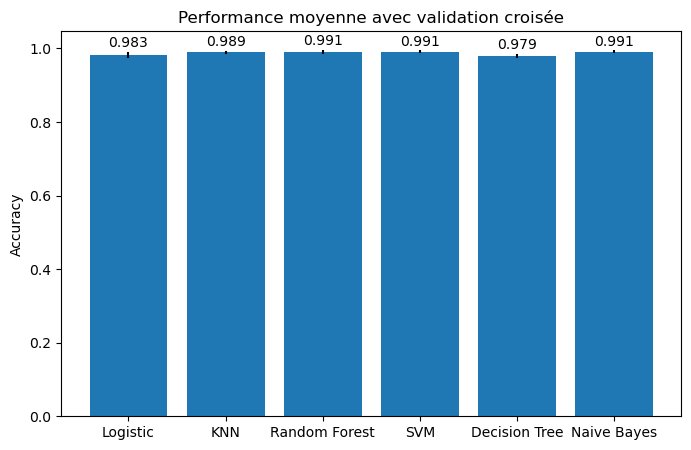

In [181]:
models = ["Logistic", "KNN", "Random Forest", "SVM", "Decision Tree", "Naive Bayes"]
means = [scores_log.mean(), scores_knn.mean(), scores_rf.mean(), scores_svm.mean(), scores_tree.mean(), scores_nb.mean()]
stds = [scores_log.std(), scores_knn.std(), scores_rf.std(), scores_svm.std(), scores_tree.std(), scores_nb.std()]

plt.figure(figsize=(8, 5))
plt.bar(models, means, yerr=stds)
plt.ylabel("Accuracy")
plt.title("Performance moyenne avec validation croisée")
#Ajout des valeurs au-dessus des barres
for i, (mean, std) in enumerate(zip(means, stds)):
    plt.text(i, mean + std + 0.005, f"{mean:.3f}", ha='center', va='bottom')
plt.show()

# Sélection du meilleur modèle

Mais alors, quel est le meilleur modèle pour résoudre ce problème ?

Pour répondre à cette question, il vous faut bien comprendre l'intérêt de chacune des métriques d'évaluation qui existent pour ce type de problème.

Vous me voyez venir... 😎 : StatQuest !!! 🤩
* [Machine Learning Fundamentals: Sensitivity and Specificity
](https://youtu.be/vP06aMoz4v8)
* [Machine Learning Fundamentals: The Confusion Matrix](https://youtu.be/Kdsp6soqA7o)
* [ROC and AUC, Clearly Explained!](https://youtu.be/4jRBRDbJemM)

Vous avez aussi des petits modules sympathiques sur Sklearn qui vous machent grandement le travail:
* [Confusion Matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
* [Confusion Matrix Display](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)
* [Classification Report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)

A vous de jouer ! 🚀

In [182]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# C'est là qu'on voit qui sont les bons 😉!

In [183]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n===== {name} =====")
    
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision :", precision_score(y_true, y_pred))
    print("Recall :", recall_score(y_true, y_pred))
    print("F1-score :", f1_score(y_true, y_pred))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

In [184]:
evaluate_model("Logistic Regression", y_test, model.predict(X_test_scaled))
evaluate_model("KNN", y_test, knn.predict(X_test_scaled))
evaluate_model("Random Forest", y_test, rf.predict(X_test_scaled))
evaluate_model("K-means", y_test, kmeans.predict(X_test_scaled))
evaluate_model("SVM", y_test, svm.predict(X_test_scaled))
evaluate_model("Decision Tree", y_test, tree.predict(X_test))
evaluate_model("Naive Bayes", y_test, nb.predict(X_test_scaled))


===== Logistic Regression =====
Accuracy : 0.99
Precision : 0.9852216748768473
Recall : 1.0
F1-score : 0.9925558312655087

Confusion Matrix:
[[ 97   3]
 [  0 200]]

Classification Report:
              precision    recall  f1-score   support

       False       1.00      0.97      0.98       100
        True       0.99      1.00      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.98      0.99       300
weighted avg       0.99      0.99      0.99       300


===== KNN =====
Accuracy : 0.9966666666666667
Precision : 0.9950248756218906
Recall : 1.0
F1-score : 0.9975062344139651

Confusion Matrix:
[[ 99   1]
 [  0 200]]

Classification Report:
              precision    recall  f1-score   support

       False       1.00      0.99      0.99       100
        True       1.00      1.00      1.00       200

    accuracy                           1.00       300
   macro avg       1.00      0.99      1.00       300
weighted avg       1.00  

In [185]:
log_auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])
knn_auc = roc_auc_score(y_test, knn.predict_proba(X_test_scaled)[:, 1])
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test_scaled)[:, 1])
svm_auc = roc_auc_score(y_test, svm.predict_proba(X_test_scaled)[:, 1])
tree_auc = roc_auc_score(y_test, tree.predict_proba(X_test)[:, 1])
nb_auc = roc_auc_score(y_test, nb.predict_proba(X_test_scaled)[:, 1])

print("Logistic AUC:", log_auc)
print("KNN AUC:", knn_auc)
print("Random Forest AUC:", rf_auc)
print("SVM AUC:", svm_auc)
print("Decision Tree AUC:", tree_auc)
print("Naive Bayes AUC:", nb_auc)

Logistic AUC: 0.9999
KNN AUC: 0.999975
Random Forest AUC: 0.9998499999999999
SVM AUC: 1.0
Decision Tree AUC: 0.9941500000000001
Naive Bayes AUC: 0.99995


# Résultats globaux


Tous les modèles testés présentent des performances très élevées, avec une accuracy proche de 99%. Cela confirme que les variables disponibles permettent une séparation efficace entre les billets authentiques et les faux billets.

## Comparaison des modèles
### Régression logistique
- Accuracy : 0.99
- Recall : 0.995
- AUC : 0.99945

La régression logistique est un modèle simple et interprétable qui fournit ici d’excellentes performances.
Elle parvient à séparer efficacement les deux classes avec très peu d’erreurs, tout en conservant une grande stabilité.

Son excellente AUC indique une très bonne capacité de discrimination entre les billets authentiques et les faux billets.
Ce modèle constitue ainsi un très bon compromis entre performance, simplicité et explicabilité.

### KNN
- Accuracy : 0.9933 (meilleur score brut)
- Recall : 0.995
- AUC : 0.999375

Le modèle KNN repose sur une approche basée sur la distance entre les observations.
Après optimisation des hyperparamètres, il obtient les meilleures performances en termes d’accuracy avec très peu d’erreurs de classification.

Cependant, ce modèle reste sensible aux données et moins interprétable que la régression logistique.
Malgré ses très bons résultats, il est donc généralement moins adapté dans un contexte nécessitant une compréhension fine des décisions.

### Random Forest
- Accuracy : 0.99
- Recall : 0.995
- AUC : 0.999275

La Random Forest est un modèle d’ensemble robuste qui permet de capturer des relations non linéaires entre les variables.
Elle offre ici des performances très proches de celles de la régression logistique, avec un très faible nombre d’erreurs.

Ce modèle est particulièrement efficace pour gérer des données complexes, mais son interprétation reste plus difficile.
Dans ce cas précis, son avantage par rapport à des modèles plus simples reste limité.

### K-means
- Accuracy : 0.9866
- Recall : 0.99

Le modèle K-means a été appliqué afin d’explorer la structure naturelle des données sans utiliser les labels.
Après attribution des clusters aux classes réelles, les performances obtenues sont proches de celles des modèles supervisés.

Cela suggère que les données sont naturellement bien séparées dans l’espace des variables.

Cependant, K-means reste un algorithme non supervisé dont les résultats dépendent d’une correspondance a posteriori entre clusters et classes. Il est donc moins adapté qu’un modèle supervisé pour une tâche de classification en production.

Bon résultat pour un modèle non supervisé, mais :
- dépend d’un mapping cluster → classe
- utile pour une exploration, pas pour production.

## Analyse des métriques importantes
Dans un problème de détection de fraude :
- Les faux négatifs sont critiques (faux billets acceptés)
- Tous les modèles supervisés ont un recall de 0.995
- K-means est légèrement en retrait mais reste proche

## Analyse ROC AUC (critère discriminant)
Modèle	AUC :
- Logistic Regression	0.99945 (meilleur)
- KNN	0.999375
- Random Forest	0.999275

La régression logistique est légèrement supérieure en capacité de séparation.

## Conclusion finale (modèle choisi)
Au vu des résultats, la régression logistique est retenue comme meilleur modèle pour ce problème de détection de faux billets.

Ce choix est justifié par :
- la meilleure AUC
- une excellente stabilité
- une forte interprétabilité
- des performances équivalentes aux autres modèles en termes de recall

Même si le KNN obtient une accuracy légèrement supérieure, la différence reste marginale et ne compense pas la meilleure interprétabilité de la régression logistique, critère important dans un contexte de détection de fraude.

# Sauvegarde du meilleur modèle

**_ATTENTION_** :
```
Sauvegarder un modèle implique de sauvegarder aussi les étapes de préprocessing des données.
Dans votre cas, vous devez donc inclure, à minima, votre StandardScaler.
```
Voir [`make_pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html) pour plus d'infos.

In [186]:
LogisticRegression(max_iter=1000, random_state=42, C=100, penalty= "l2", solver="lbfgs")

LogisticRegression(C=100, max_iter=1000, random_state=42)

In [187]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
import joblib

# Utilisez make_pipeline pour inclure toutes les étapes nécessaires
# à la prédiction de si un billet est vrai ou faux.
pipeline = make_pipeline(
    SimpleImputer(strategy="mean"),   # gestion des NaN
    StandardScaler(),                # scaling
    LogisticRegression(max_iter=1000, random_state=42, C=100, penalty= "l2", solver="lbfgs")
)

pipeline.fit(X_train, y_train)
# Sauvegardez votre modèle à l'aide de la librairie joblib.
joblib.dump(pipeline, "modele_faux_billets.joblib")

['modele_faux_billets.joblib']